In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv('../GSE68086_TEP_data_matrix.csv')
series = pd.read_csv('../GSE68086_series_matrix.csv')
data_df = pd.DataFrame(data)
series_df = pd.DataFrame(series)

### data: these are the raw counts

In [3]:
data_df.head()

,Unnamed: 0,3-Breast-Her2-ampl,8-Breast-WT,10-Breast-Her2-ampl,Breast-100,15-Breast-Her2-ampl,16-Breast-WT,21-Breast-WT,33-Breast-Her2-ampl,42-Breast-Her2-ampl,...,MGH-NSCLC-L20-TR500,MGH-NSCLC-L22-TR462,MGH-NSCLC-L23-TR524,MGH-NSCLC-L25-TR480,MGH-NSCLC-L39-TR519,MGH-NSCLC-L40-TR520,MGH-NSCLC-L51-TR521,MGH-NSCLC-L58-TR525,MGH-NSCLC-L59-TR522,MGH-NSCLC-L65-TR523
0,ENSG00000000003,0,0,0,0,17,0,0,0,0,...,0,5,10,9,0,0,0,0,0,0
1,ENSG00000000005,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ENSG00000000419,44,14,16,8,9,0,139,108,55,...,2,41,40,15,1,0,13,0,0,10
3,ENSG00000000457,26,1,14,0,4,20,1,26,24,...,0,0,0,0,0,0,0,0,0,0
4,ENSG00000000460,81,98,18,17,0,20,144,26,97,...,23,1,6,22,30,0,1,50,6,2


In [4]:
data_df.shape

(57736, 286)

In [5]:
data_df.nunique()

Unnamed: 0             57736
3-Breast-Her2-ampl      1120
8-Breast-WT             1051
10-Breast-Her2-ampl     1022
Breast-100               611
                       ...  
MGH-NSCLC-L40-TR520      709
MGH-NSCLC-L51-TR521      888
MGH-NSCLC-L58-TR525     1061
MGH-NSCLC-L59-TR522      741
MGH-NSCLC-L65-TR523      965
Length: 286, dtype: int64

### series: pacient data

In [6]:
series_df.shape

(285, 46)

In [7]:
series_df.head(20)

,!Sample_geo_accession,!Sample_status,!Sample_submission_date,!Sample_last_update_date,!Sample_type,!Sample_channel_count,!Sample_source_name_ch1,!Sample_organism_ch1,!Sample_characteristics_ch1,!Sample_characteristics_ch1.1,...,!Sample_instrument_model,!Sample_library_selection,!Sample_library_source,!Sample_library_strategy,!Sample_relation,!Sample_relation.1,!Sample_supplementary_file_1,!series_matrix_table_begin,"""ID_REF""",!series_matrix_table_end
0,"""GSM1662534""","""Public on Oct 30 2015""","""Apr 21 2015""","""May 15 2019""","""SRA""","""1""","""3-Breast-Her2-ampl""","""Homo sapiens""","""tissue: blood""","""cell type: Thrombocytes""",...,"""Illumina HiSeq 2500""","""cDNA""","""transcriptomic""","""RNA-Seq""","""BioSample: https://www.ncbi.nlm.nih.gov/biosa...","""SRA: https://www.ncbi.nlm.nih.gov/sra?term=SR...","""NONE""",NaN,"""GSM1662534""",NaN
1,"""GSM1662535""","""Public on Oct 30 2015""","""Apr 21 2015""","""May 15 2019""","""SRA""","""1""","""8-Breast-WT""","""Homo sapiens""","""tissue: blood""","""cell type: Thrombocytes""",...,"""Illumina HiSeq 2500""","""cDNA""","""transcriptomic""","""RNA-Seq""","""BioSample: https://www.ncbi.nlm.nih.gov/biosa...","""SRA: https://www.ncbi.nlm.nih.gov/sra?term=SR...","""NONE""",NaN,"""GSM1662535""",NaN
2,"""GSM1662536""","""Public on Oct 30 2015""","""Apr 21 2015""","""May 15 2019""","""SRA""","""1""","""10-Breast-Her2-ampl""","""Homo sapiens""","""tissue: blood""","""cell type: Thrombocytes""",...,"""Illumina HiSeq 2500""","""cDNA""","""transcriptomic""","""RNA-Seq""","""BioSample: https://www.ncbi.nlm.nih.gov/biosa...","""SRA: https://www.ncbi.nlm.nih.gov/sra?term=SR...","""NONE""",NaN,"""GSM1662536""",NaN
3,"""GSM1662537""","""Public on Oct 30 2015""","""Apr 21 2015""","""May 15 2019""","""SRA""","""1""","""Breast-100""","""Homo sapiens""","""tissue: blood""","""cell type: Thrombocytes""",...,"""Illumina HiSeq 2500""","""cDNA""","""transcriptomic""","""RNA-Seq""","""BioSample: https://www.ncbi.nlm.nih.gov/biosa...","""SRA: https://www.ncbi.nlm.nih.gov/sra?term=SR...","""NONE""",NaN,"""GSM1662537""",NaN
4,"""GSM1662538""","""Public on Oct 30 2015""","""Apr 21 2015""","""May 15 2019""","""SRA""","""1""","""15-Breast-Her2-ampl""","""Homo sapiens""","""tissue: blood""","""cell type: Thrombocytes""",...,"""Illumina HiSeq 2500""","""cDNA""","""transcriptomic""","""RNA-Seq""","""BioSample: https://www.ncbi.nlm.nih.gov/biosa...","""SRA: https://www.ncbi.nlm.nih.gov/sra?term=SR...","""NONE""",NaN,"""GSM1662538""",NaN
5,"""GSM1662539""","""Public on Oct 30 2015""","""Apr 21 2015""","""May 15 2019""","""SRA""","""1""","""16-Breast-WT""","""Homo sapiens""","""tissue: blood""","""cell type: Thrombocytes""",...,"""Illumina HiSeq 2500""","""cDNA""","""transcriptomic""","""RNA-Seq""","""BioSample: https://www.ncbi.nlm.nih.gov/biosa...","""SRA: https://www.ncbi.nlm.nih.gov/sra?term=SR...","""NONE""",NaN,"""GSM1662539""",NaN
6,"""GSM1662540""","""Public on Oct 30 2015""","""Apr 21 2015""","""May 15 2019""","""SRA""","""1""","""21-Breast-WT""","""Homo sapiens""","""tissue: blood""","""cell type: Thrombocytes""",...,"""Illumina HiSeq 2500""","""cDNA""","""transcriptomic""","""RNA-Seq""","""BioSample: https://www.ncbi.nlm.nih.gov/biosa...","""SRA: https://www.ncbi.nlm.nih.gov/sra?term=SR...","""NONE""",NaN,"""GSM1662540""",NaN
7,"""GSM1662541""","""Public on Oct 30 2015""","""Apr 21 2015""","""May 15 2019""","""SRA""","""1""","""33-Breast-Her2-ampl""","""Homo sapiens""","""tissue: blood""","""cell type: Thrombocytes""",...,"""Illumina HiSeq 2500""","""cDNA""","""transcriptomic""","""RNA-Seq""","""BioSample: https://www.ncbi.nlm.nih.gov/biosa...","""SRA: https://www.ncbi.nlm.nih.gov/sra?term=SR...","""NONE""",NaN,"""GSM1662541""",NaN
8,"""GSM1662542""","""Public on Oct 30 2015""","""Apr 21 2015""","""May 15 2019""","""SRA""","""1""","""42-Breast-Her2-ampl""","""Homo sapiens""","""tissue: blood""","""cell type: Thrombocytes""",...,"""Illumina HiSeq 2500""","""cDNA""","""transcriptomic""","""R

In [8]:
series_df.columns.str.strip()

Index(['!Sample_geo_accession', '!Sample_status', '!Sample_submission_date',
       '!Sample_last_update_date', '!Sample_type', '!Sample_channel_count',
       '!Sample_source_name_ch1', '!Sample_organism_ch1',
       '!Sample_characteristics_ch1', '!Sample_characteristics_ch1.1',
       '!Sample_characteristics_ch1.2', '!Sample_characteristics_ch1.3',
       '!Sample_characteristics_ch1.4', '!Sample_characteristics_ch1.5',
       '!Sample_molecule_ch1', '!Sample_extract_protocol_ch1',
       '!Sample_extract_protocol_ch1.1', '!Sample_taxid_ch1',
       '!Sample_description', '!Sample_data_processing',
       '!Sample_data_processing.1', '!Sample_data_processing.2',
       '!Sample_data_processing.3', '!Sample_data_processing.4',
       '!Sample_data_processing.5', '!Sample_platform_id',
       '!Sample_contact_name', '!Sample_contact_email',
       '!Sample_contact_laboratory', '!Sample_contact_department',
       '!Sample_contact_institute', '!Sample_contact_address',
       '!Sample

In [9]:
series_df.groupby("!Sample_characteristics_ch1.4")["!Sample_submission_date"].apply(list)

!Sample_characteristics_ch1.4
"batch: Batch01"                       ["Apr 21 2015", "Apr 21 2015"]
"batch: Batch02"    ["Apr 21 2015", "Apr 21 2015", "Apr 21 2015", ...
"batch: Batch03"    ["Apr 21 2015", "Apr 21 2015", "Apr 21 2015", ...
"batch: Batch04"    ["Apr 21 2015", "Apr 21 2015", "Apr 21 2015", ...
"tissue: blood"     ["Jul 10 2015", "Jul 10 2015", "Jul 10 2015", ...
Name: !Sample_submission_date, dtype: object

In [10]:
series_df['!Sample_submission_date'].value_counts()

!Sample_submission_date
"Apr 21 2015"    245
"Jul 10 2015"     40
Name: count, dtype: int64

### series tidy

In [11]:
def unquote(x):
    '''GEO values arrive triple-quoted through the CSV round-trip: "\"\"\"GSM1662534\"\"\"".'''
    return np.nan if pd.isna(x) else str(x).strip().strip('"')

series_clean = series_df.map(unquote)    # working copy, in memory only
series_df.shape

ch_cols = [c for c in series_clean.columns if c.startswith("!Sample_characteristics_ch1")]

key_of = lambda s: s.split(":")[0].strip() if isinstance(s, str) and ":" in s else "<no key>"
key_pattern = series_clean[ch_cols].apply(lambda row: tuple(key_of(v) for v in row), axis=1)

# print(key_pattern.value_counts().to_string(), "\n")
# ...and the 40 rotated rows are exactly the second submission wave:
# print(pd.crosstab(series_clean["!Sample_submission_date"],
                #   key_pattern.map(lambda p: "rotated" if p[0] != "tissue" else "original")))

# 3. Parse by key -> tidy sample sheet: the same columns as 01_sample sheet creation.R, plus gsm.
#    (Mirrors what GEOquery's pData() hands the R scripts, which is why
#     01_sample sheet creation.R is unaffected by the key-order shift.)
def parse_characteristics(row):
    out = {}
    for v in row:
        if isinstance(v, str) and ":" in v:
            k, _, val = v.partition(":")
            out[k.strip()] = val.strip()
    return pd.Series(out)

chars = series_clean[ch_cols].apply(parse_characteristics, axis=1).rename(
    columns={"cancer type": "group", "patient id": "patient", "mutational subclass": "subclass"}
)

series_tidy = pd.concat(
    [
        series_clean["!Sample_source_name_ch1"].rename("sample"),   # join key to the counts
        series_clean["!Sample_geo_accession"].rename("gsm"),
        chars[["batch", "group", "subclass", "patient"]],
    ],
    axis=1,
)

# Deliberately left out: 'tissue' (always blood) and 'cell type' (always thrombocytes) are constant,
# and 'submission_date' / the !Sample_description note stay in series_clean if ever needed.
print(list(series_tidy.columns))
series_tidy.head()

['sample', 'gsm', 'batch', 'group', 'subclass', 'patient']


,sample,gsm,batch,group,subclass,patient
0,3-Breast-Her2-ampl,GSM1662534,Batch03,Breast,HER2+,Breast-03
1,8-Breast-WT,GSM1662535,Batch03,Breast,wt,Breast-08
2,10-Breast-Her2-ampl,GSM1662536,Batch03,Breast,HER2+,Breast-10
3,Breast-100,GSM1662537,Batch04,Breast,Triple Negative,Breast-100
4,15-Breast-Her2-ampl,GSM1662538,Batch03,Breast,HER2+,Breast-15


In [12]:
# 4. The variables, and the batch/group confounding that 04_DESeq2.R models with ~ batch + group
for col in ["group", "batch", "subclass"]:
    print(f"--- {col} ---")
    print(series_tidy[col].value_counts().to_string(), "\n")

print("patients:", series_tidy.patient.nunique(), "unique for", len(series_tidy), "samples",
      "-> one sample per patient\n")
pd.crosstab(series_tidy.group, series_tidy.batch, margins=True)

--- group ---
group
Lung             60
HC               55
CRC              42
GBM              40
Breast           39
Pancreas         35
Hepatobiliary    14 

--- batch ---
batch
Batch03    103
Batch04     87
Batch02     53
Batch06     30
Batch05     10
Batch01      2 

--- subclass ---
subclass
wt                 175
KRAS                63
EGFR                13
HER2+               10
EGFR, MET            8
Triple Negative      6
PIK3CA               6
HER2+, PIK3CA        2
MET                  1
KRAS, MET            1 

patients: 285 unique for 285 samples -> one sample per patient



batch,Batch01,Batch02,Batch03,Batch04,Batch05,Batch06,All
group,,,,,,,
Breast,0,0,15,9,6,9,39
CRC,0,4,21,13,1,3,42
GBM,2,12,15,11,0,0,40
HC,0,16,15,24,0,0,55
Hepatobiliary,0,1,7,5,0,1,14
Lung,0,19,7,14,3,17,60
Pancreas,0,1,23,11,0,0,35
All,2,53,103,87,10,30,285


In [13]:
gene_batch = pd.crosstab(series_tidy.group, series_tidy.batch, margins=True)
print("batch 02", gene_batch["Batch02"].sum())
print("batch 03", gene_batch["Batch03"].sum())
print("batch 04", gene_batch["Batch04"].sum())

batch 02 106
batch 03 206
batch 04 174


In [14]:
# 5. How many samples each disease has in each batch.
#    Pick the diseases here; an empty list shows them all.
#    Options: Breast, CRC, GBM, HC, Hepatobiliary, Lung, Pancreas
diseases = []          # e.g. ["Lung", "HC", "GBM"]

#    No margins here: a totals row inside the table gets added again by .sum(), so every
#    count would be doubled. The totals are computed from the plain table instead.
disease_by_batch = pd.crosstab(series_tidy.group, series_tidy.batch)

if diseases:
    unknown = [d for d in diseases if d not in disease_by_batch.index]
    if unknown:
        raise KeyError(f"not a disease in the sample sheet: {unknown}. "
                       f"Choose from {list(disease_by_batch.index)}")
    disease_by_batch = disease_by_batch.loc[diseases]
    # drop batches that hold none of the chosen diseases, so the table stays readable
    disease_by_batch = disease_by_batch.loc[:, disease_by_batch.sum(axis=0) > 0]

print("samples per disease in each batch")
print(disease_by_batch.to_string(), "\n")

print("samples per batch")
print(disease_by_batch.sum(axis=0).to_string(), "\n")

print("samples per disease")
print(disease_by_batch.sum(axis=1).to_string(), "\n")

print("total samples:", disease_by_batch.to_numpy().sum())

disease_by_batch

samples per disease in each batch
batch          Batch01  Batch02  Batch03  Batch04  Batch05  Batch06
group                                                              
Breast               0        0       15        9        6        9
CRC                  0        4       21       13        1        3
GBM                  2       12       15       11        0        0
HC                   0       16       15       24        0        0
Hepatobiliary        0        1        7        5        0        1
Lung                 0       19        7       14        3       17
Pancreas             0        1       23       11        0        0 

samples per batch
batch
Batch01      2
Batch02     53
Batch03    103
Batch04     87
Batch05     10
Batch06     30 

samples per disease
group
Breast           39
CRC              42
GBM              40
HC               55
Hepatobiliary    14
Lung             60
Pancreas         35 

total samples: 285


batch,Batch01,Batch02,Batch03,Batch04,Batch05,Batch06
group,,,,,,
Breast,0,0,15,9,6,9
CRC,0,4,21,13,1,3
GBM,2,12,15,11,0,0
HC,0,16,15,24,0,0
Hepatobiliary,0,1,7,5,0,1
Lung,0,19,7,14,3,17
Pancreas,0,1,23,11,0,0


In [18]:
# 6. Reads per disease in each batch, to sit next to the sample counts above.
#    Pick the diseases here; an empty list shows them all.
#    Options: Breast, CRC, GBM, HC, Hepatobiliary, Lung, Pancreas
diseases = ["Lung", "GBM", "HC"]          # e.g. ["Lung", "HC", "GBM"]

counts = data_df.set_index("Unnamed: 0")            # genes in rows, samples in columns
reads_per_sample = counts.sum(axis=0).rename("reads")   # all genes added up, one number per sample

# The counts matrix and the sample sheet hold the same 285 sample names but not in the same
# order, so they are joined by name; pairing them by position would mix up the samples.
per_sample = series_tidy.set_index("sample").join(reads_per_sample, how="inner")
assert len(per_sample) == len(series_tidy), "some samples did not match by name"

if diseases:
    unknown = [d for d in diseases if d not in set(series_tidy.group)]
    if unknown:
        raise KeyError(f"not a disease in the sample sheet: {unknown}. "
                       f"Choose from {sorted(series_tidy.group.unique())}")
    per_sample = per_sample[per_sample.group.isin(diseases)]

total_reads = per_sample.pivot_table(index="group", columns="batch", values="reads",
                                     aggfunc="sum", fill_value=0)
median_reads = per_sample.pivot_table(index="group", columns="batch", values="reads",
                                      aggfunc="median")
if diseases:
    total_reads = total_reads.loc[diseases]
    median_reads = median_reads.loc[diseases]
    keep = total_reads.sum(axis=0) > 0      # same batch columns as the table above
    total_reads, median_reads = total_reads.loc[:, keep], median_reads.loc[:, keep]

print("total reads, in millions")
print((total_reads / 1e6).round(1).to_string(), "\n")

print("reads per batch, in millions")
print((total_reads.sum(axis=0) / 1e6).round(1).to_string(), "\n")

print("reads per disease, in millions")
print((total_reads.sum(axis=1) / 1e6).round(1).to_string(), "\n")

print("all reads, in millions:", round(total_reads.to_numpy().sum() / 1e6, 1), "\n")

# The totals above follow the sample counts, so the typical sample is the fairer comparison:
print("median reads per sample, in millions (empty = no samples there)")
print((median_reads / 1e6).round(2).to_string(na_rep="-"))

total_reads

total reads, in millions
batch  Batch01  Batch02  Batch03  Batch04  Batch05  Batch06
group                                                      
Lung       0.0     53.1     19.0     20.9      5.8     36.6
GBM        7.0     28.2     23.6     15.3      0.0      0.0
HC         0.0     38.7     34.5     15.9      0.0      0.0 

reads per batch, in millions
batch
Batch01      7.0
Batch02    120.1
Batch03     77.1
Batch04     52.1
Batch05      5.8
Batch06     36.6 

reads per disease, in millions
group
Lung    135.3
GBM      74.1
HC       89.2 

all reads, in millions: 298.6 

median reads per sample, in millions (empty = no samples there)
batch  Batch01  Batch02  Batch03  Batch04  Batch05  Batch06
group                                                      
Lung         -     2.64     3.12     1.56     1.83     2.17
GBM       3.51     2.06     1.38     1.36        -        -
HC           -     2.52     2.69     0.59        -        -


batch,Batch01,Batch02,Batch03,Batch04,Batch05,Batch06
group,,,,,,
Lung,0,53117108,18964404,20871378,5764757,36613396
GBM,7018333,28220667,23559307,15343426,0,0
HC,0,38731637,34544252,15881991,0,0


reads per sample in millions, by batch
         samples  shallowest  median  deepest
batch                                        
Batch01        2        3.03    3.51     3.99
Batch02       53        0.22    2.59     7.27
Batch03      103        0.51    2.66     4.47
Batch04       87        0.42    1.30     3.14
Batch05       10        0.38    1.51     2.28
Batch06       30        1.05    2.26     3.54 

reads per sample in millions, by disease
               samples  shallowest  median  deepest
group                                              
Breast              39        0.38    2.39     3.90
CRC                 42        0.22    2.33     4.47
GBM                 40        0.40    1.73     4.50
HC                  55        0.42    1.04     4.09
Hepatobiliary       14        0.99    1.91     3.73
Lung                60        0.59    2.04     7.27
Pancreas            35        0.89    2.29     4.00 

the 5 shallowest samples
                group    batch  millions
sample        

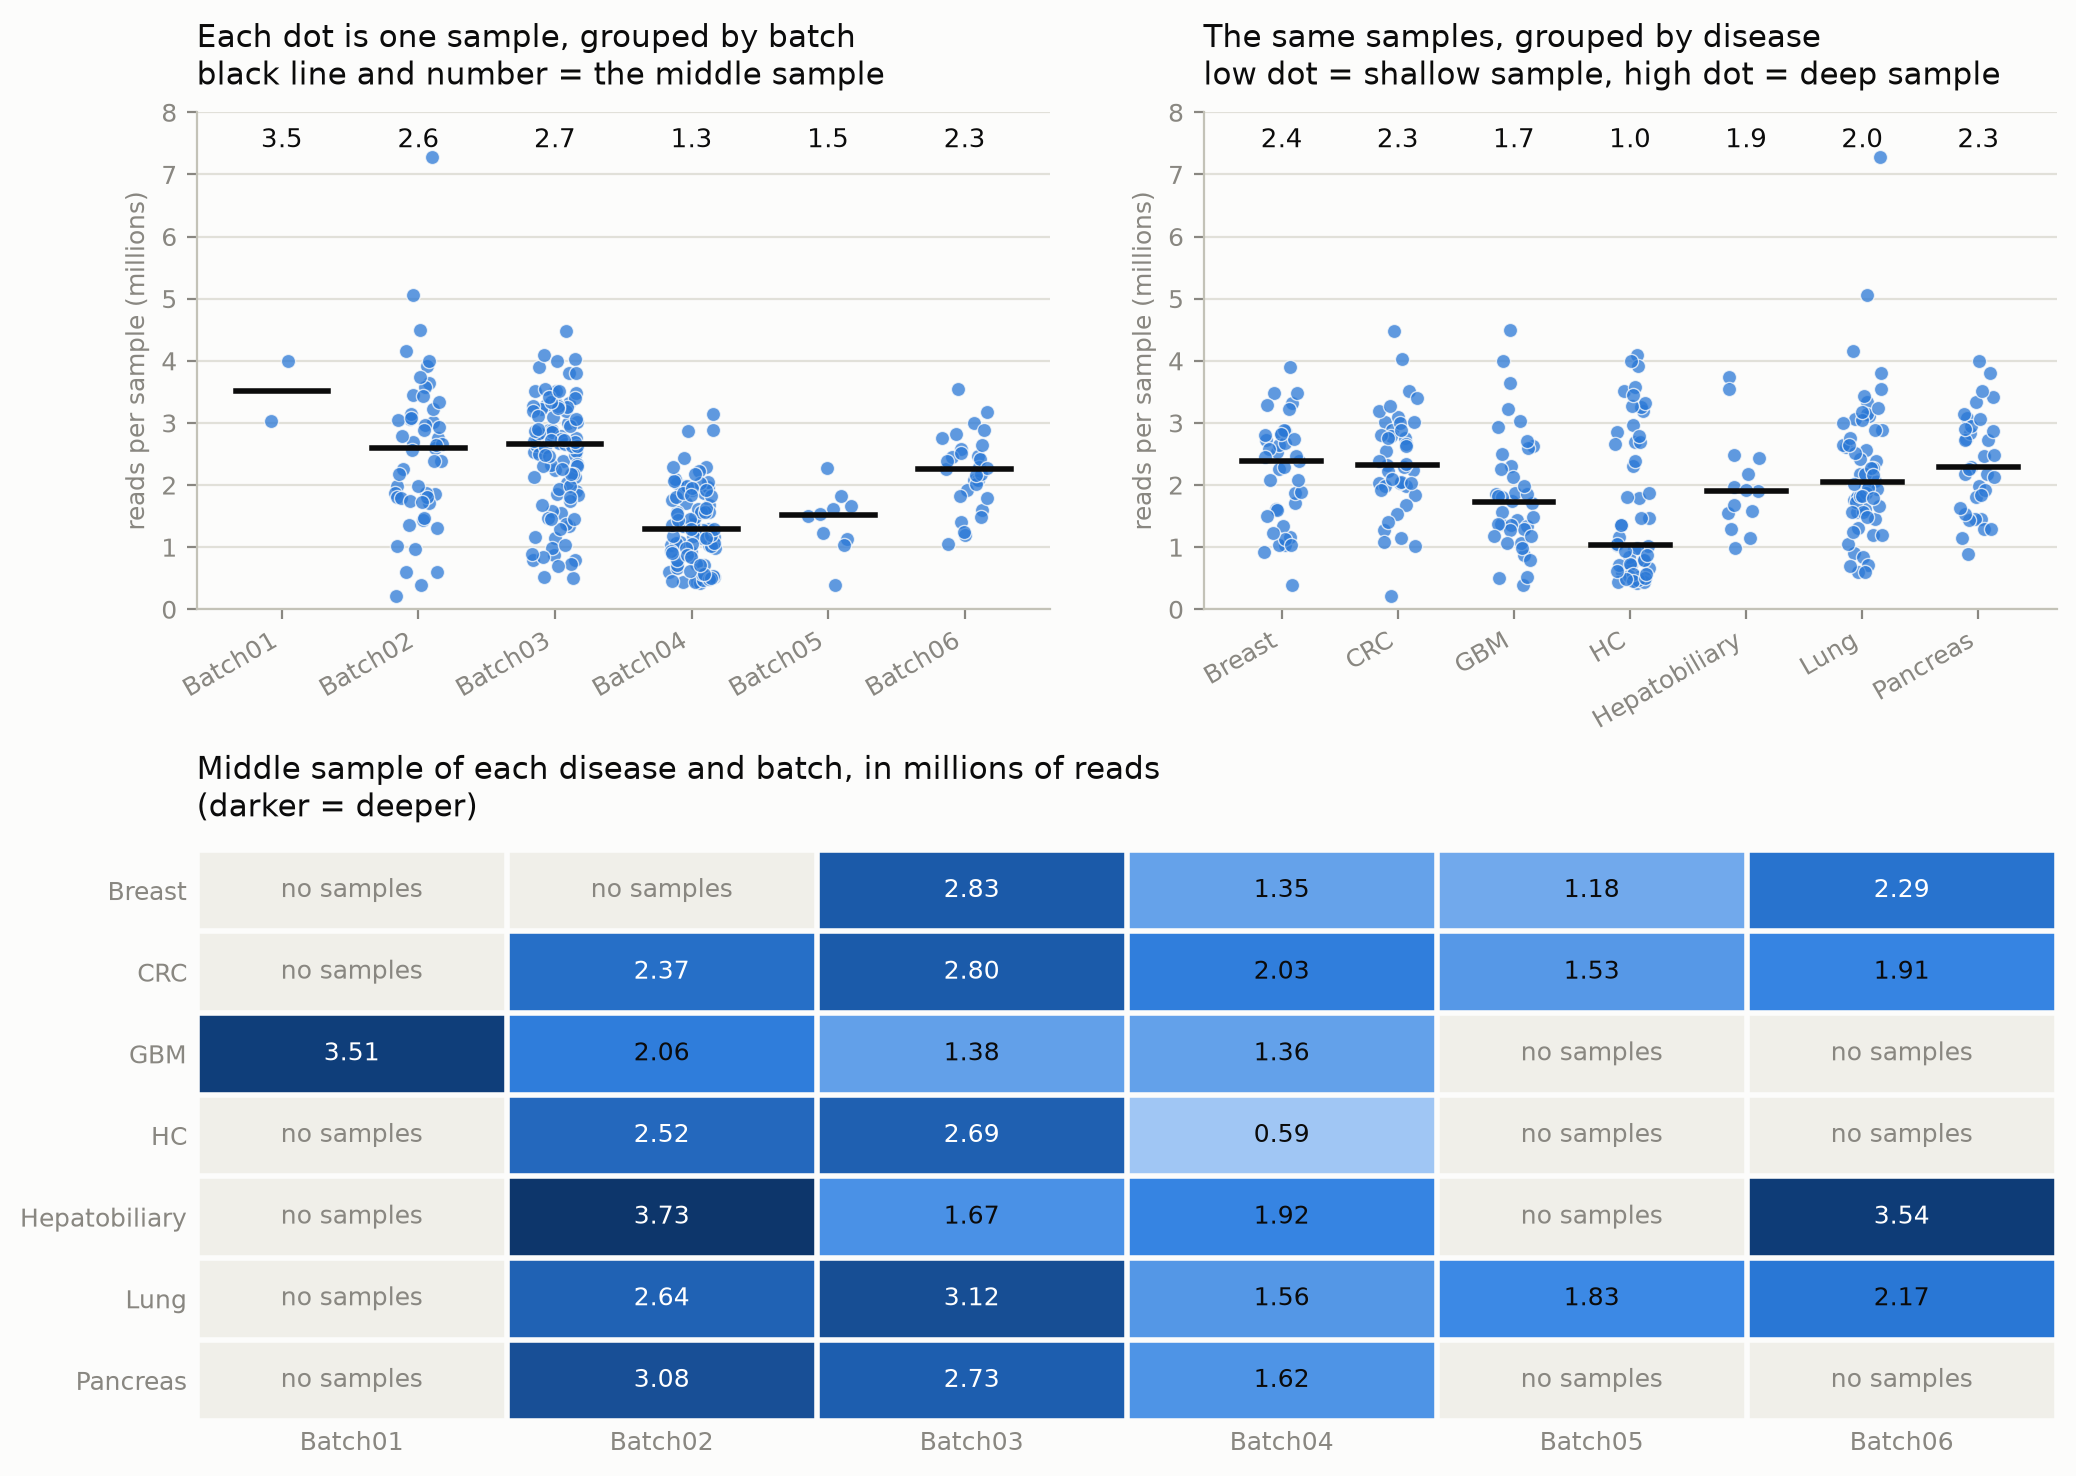

In [17]:
# 7. Depth: how many reads one sample got.
#    Every sample is one dot. A dot low down got few reads -> shallow.
#    A dot high up got many reads -> deep. Depth is how much sequencing
#    the sample received, not how sick the patient is.
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

depth = (series_tidy.set_index("sample")
         .join(reads_per_sample)                       # reads_per_sample comes from cell 6
         .assign(millions=lambda d: d.reads / 1e6))

# ---- the numbers ----
def spread(by):
    return (depth.groupby(by).millions
            .agg(samples="size", shallowest="min", median="median", deepest="max")
            .round(2))

print("reads per sample in millions, by batch")
print(spread("batch").to_string(), "\n")

print("reads per sample in millions, by disease")
print(spread("group").to_string(), "\n")

print("the 5 shallowest samples")
print(depth.nsmallest(5, "millions")[["group", "batch", "millions"]].to_string(), "\n")

print("the 5 deepest samples")
print(depth.nlargest(5, "millions")[["group", "batch", "millions"]].to_string(), "\n")

print(f"deepest sample has {depth.millions.max() / depth.millions.min():.0f}x "
      f"the reads of the shallowest one")

# ---- the picture ----
INK, MUTED, GRID, SURFACE = "#0b0b0b", "#898781", "#e1e0d9", "#fcfcfb"
DOT = "#2a78d6"
BLUES = LinearSegmentedColormap.from_list("blues", [
    "#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7", "#3987e5",
    "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"])

fig = plt.figure(figsize=(12, 8.5), facecolor=SURFACE)
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.15], hspace=0.45, wspace=0.18)
rng = np.random.default_rng(0)

def dots(ax, by, title):
    """One dot per sample, plus a line at the middle sample of each column."""
    names = sorted(depth[by].unique())
    top = depth.millions.max() * 1.10
    ax.set_ylim(0, top)
    for x, name in enumerate(names):
        vals = depth.loc[depth[by] == name, "millions"].to_numpy()
        ax.scatter(x + rng.uniform(-0.17, 0.17, len(vals)), vals, s=26, color=DOT,
                   alpha=0.75, edgecolor=SURFACE, linewidth=0.5, zorder=3)
        med = np.median(vals)
        ax.plot([x - 0.34, x + 0.34], [med, med], color=INK, linewidth=2, zorder=4)
        ax.text(x, top * 0.97, f"{med:.1f}", ha="center", va="top",
                fontsize=9.5, color=INK, zorder=5)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=30, ha="right")
    ax.set_title(title, fontsize=11, color=INK, pad=10, loc="left")
    ax.set_ylabel("reads per sample (millions)", fontsize=9, color=MUTED)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color("#c3c2b7")
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.set_facecolor(SURFACE)

ax1 = fig.add_subplot(gs[0, 0])
dots(ax1, "batch", "Each dot is one sample, grouped by batch\nblack line and number = the middle sample")
ax2 = fig.add_subplot(gs[0, 1])
dots(ax2, "group", "The same samples, grouped by disease\nlow dot = shallow sample, high dot = deep sample")

# heatmap: the middle sample of every disease x batch square
ax3 = fig.add_subplot(gs[1, :])
grid = depth.pivot_table(index="group", columns="batch", values="millions", aggfunc="median")
img = ax3.imshow(np.ma.masked_invalid(grid.to_numpy()), cmap=BLUES, aspect="auto",
                 vmin=0, vmax=np.nanmax(grid.to_numpy()))
img.cmap.set_bad("#f0efe9")
ax3.set_xticks(range(grid.shape[1]), grid.columns)
ax3.set_yticks(range(grid.shape[0]), grid.index)
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        v = grid.to_numpy()[i, j]
        label = "no samples" if np.isnan(v) else f"{v:.2f}"
        colour = MUTED if np.isnan(v) else ("#ffffff" if v > np.nanmax(grid.to_numpy()) * 0.6 else INK)
        ax3.text(j, i, label, ha="center", va="center", fontsize=9, color=colour)
ax3.set_title("Middle sample of each disease and batch, in millions of reads\n"
              "(darker = deeper)", fontsize=11, color=INK, pad=12, loc="left")
ax3.tick_params(colors=MUTED, labelsize=9, length=0)
for s in ax3.spines.values():
    s.set_visible(False)
ax3.set_xticks(np.arange(-0.5, grid.shape[1], 1), minor=True)
ax3.set_yticks(np.arange(-0.5, grid.shape[0], 1), minor=True)
ax3.grid(which="minor", color=SURFACE, linewidth=2)
ax3.tick_params(which="minor", length=0)

plt.show()